# Arquitetura Própria — GTSRB
Experimento opcional - comparação da arquitetura baseline com uma arquitetura criada pelo próprio grupo

In [1]:
!pip install -q torch torchvision seaborn

### 1. SETUP

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import copy
import json

from src.gtsrb import NUM_CLASSES, GTSRB_CLASSES, get_dataloaders, save_predictions


In [3]:
model_pth_path = '/content/models_pth'
if not os.path.exists(model_pth_path):
    os.mkdir(model_pth_path)

figs_path = '/content/figs'
if not os.path.exists(figs_path):
    os.mkdir(figs_path)

checkpoints_path = '/content/checkpoints'
if not os.path.exists(checkpoints_path):
    os.mkdir(checkpoints_path)

# pasta usada nos plt.savefig() -- mesmo nome que o .tex do relatorio espera
os.makedirs("figuras", exist_ok=True)

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


### 2. Hiperparâmetros

In [4]:
IMG_SIZE = 32
BATCH_SIZE = 128
NUM_EPOCHS = 30
LR = 1e-3


In [5]:
train_loader, val_loader, test_loader = get_dataloaders(img_size=IMG_SIZE, batch_size=BATCH_SIZE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")


100%|██████████| 187M/187M [00:16<00:00, 11.0MB/s]
100%|██████████| 89.0M/89.0M [00:09<00:00, 9.28MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 209kB/s]


Usando dispositivo: cuda


In [6]:
print(f"NUM_CLASSES = {NUM_CLASSES}")
print(f"train_loader = {len(train_loader)} batches")
print(f"val_loader = {len(val_loader)} batches")
print(f"test_loader = {len(test_loader)} batches")

for x, y in train_loader:
    print("Formato das imagens:", x.shape)
    print("Formato dos rótulos:", y.shape)
    break


NUM_CLASSES = 43
train_loader = 167 batches
val_loader = 42 batches
test_loader = 99 batches
Formato das imagens: torch.Size([128, 3, 32, 32])
Formato dos rótulos: torch.Size([128])


### 3. Modelo rede neural

### 3.1 Classe para Rede Neural - Baseline (EHMNet)

In [7]:
class EHMNet(nn.Module):
    def __init__(self, num_classes: int = 43, img_size: int = 32):
        super(EHMNet, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding='same')
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding='same')
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        spatial = img_size // 4
        flatten_size = 64 * spatial * spatial
        self.fc1 = nn.Linear(in_features=flatten_size, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool2(x)

        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x


### 3.2 Classe para Rede Neural - Arquitetura Própria

**Justificativa de design:** a arquitetura própria combina três mudanças em relação ao baseline:

- **Mais profundidade** -- um terceiro bloco convolucional (64→128 canais), permitindo capturar padrões mais abstratos
- **Mais largura** -- o último bloco usa 128 canais em vez de 64, aumentando a capacidade de representação
- **Dropout (0.5)** -- adicionado entre as camadas totalmente conectadas como regularização, para compensar o risco de overfitting trazido pelo aumento de capacidade

Essa combinação foi escolhida por ser a mais equilibrada: profundidade/largura sozinhas aumentam o risco de overfitting (o modelo memoriza o treino sem generalizar melhor), enquanto o dropout funciona como uma "rede de segurança" que permite usar essa capacidade extra com mais segurança.

In [8]:
class EHMNet_Custom(nn.Module):
    def __init__(self, num_classes: int = 43, img_size: int = 32, dropout: float = 0.5):
        super(EHMNet_Custom, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, stride=1, padding='same')
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding='same')
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding='same')
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        spatial = img_size // 8
        flatten_size = 128 * spatial * spatial
        self.fc1 = nn.Linear(in_features=flatten_size, out_features=256)
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(in_features=256, out_features=num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = torch.relu(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = torch.relu(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = torch.relu(x)
        x = self.pool3(x)

        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        return x


### 4. Funções para Cálculo e Comparação das Métricas

In [9]:
def train_one_epoch(trainloader, model, criterion, optimizer, device) -> tuple[float, float]:
    model.train()  # ativa o modo de treino (importante caso haja BatchNorm/Dropout)
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return total_loss/total, correct/total


def validate(val_loader, model, criterion, device) -> tuple[float, float]:
    model.eval()  # ativa o modo de avaliacao (desliga o Dropout, usa estatisticas acumuladas de BN se houver)
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    return total_loss/total, correct/total


def get_confusion_matrix(loader, model, device, num_class=NUM_CLASSES) -> torch.Tensor:
    model.eval()
    cm = torch.zeros(num_class, num_class, dtype=torch.int64)

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            for t, p in zip(labels, predicted):
                cm[t, p] += 1
    return cm


def plot_confusion_matrix(cm, title='Matriz de Confusão', save_path=None, ax=None):
    nomes_classes = [GTSRB_CLASSES[i] for i in range(NUM_CLASSES)]
    standalone = ax is None
    if standalone:
        plt.figure(figsize=(12, 10))
        ax = plt.gca()

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=nomes_classes, yticklabels=nomes_classes, ax=ax)

    ax.set_ylabel('Valores Reais')
    ax.set_xlabel('Valores Previstos')
    ax.set_title(title)

    if standalone:
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()


def predict(loader, model, device):
    model.eval()
    ytrue, ypred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            pred = model(images).argmax(1).cpu().numpy()
            ytrue.append(labels.numpy())
            ypred.append(pred)
    return np.concatenate(ytrue), np.concatenate(ypred)


def per_class_accuracy(y_true, y_pred, num_classes=NUM_CLASSES) -> torch.Tensor:
    accs = torch.zeros(num_classes)
    for c in range(num_classes):
        mask = (y_true == c)
        total = float(mask.sum())
        accs[c] = float((y_pred[mask] == c).sum()) / total if total > 0 else float('nan')
    return accs


def relatorio_por_classe(cm, class_names=GTSRB_CLASSES, nome_modelo=""):
    """Calcula acurácia por classe (recall), acurácia global e macro accuracy."""
    cm = cm.numpy() if hasattr(cm, "numpy") else np.asarray(cm)
    suporte = cm.sum(axis=1)
    acertos = np.diag(cm)
    acc_classe = np.divide(acertos, suporte,
                           out=np.zeros(len(cm), dtype=float), where=suporte > 0)

    overall = acertos.sum() / cm.sum()
    macro_acc = acc_classe.mean()

    df = pd.DataFrame({
        "classe":   [class_names[i] for i in range(len(cm))],
        "suporte":  suporte.astype(int),
        "acertos":  acertos.astype(int),
        "acuracia": acc_classe.round(4),
    })

    print(f"=== {nome_modelo} ===")
    print(f"Acurácia global (overall): {overall:.4f}")
    print(f"Macro accuracy (média por classe): {macro_acc:.4f}\n")
    print("5 piores classes:")
    print(df.sort_values("acuracia").head(5).to_string(index=False))
    print()
    print("5 melhores classes:")
    print(df.sort_values("acuracia", ascending=False).head(5).to_string(index=False))
    print()
    return df, overall, macro_acc


### Funções de salvamento e carregamento de modelos

In [26]:
def save_model_state(state_dict, file_name, path=model_pth_path):
    PATH = f'{path}/{file_name}'
    torch.save(state_dict, PATH)
    return PATH


def load_model(file_name, model_class, path=model_pth_path, **kwargs):
    PATH = f'{path}/{file_name}'
    model = model_class(**kwargs)
    model.load_state_dict(torch.load(PATH))
    return model


### 5. Função de treino completo (Baseline e Arquitetura Própria)

In [11]:
def run_experiment(model, model_name, train_loader, val_loader, num_epochs, lr, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0.0
    best_epoch = 0
    best_state = None

    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(train_loader, model, criterion, optimizer, device)
        val_loss, val_acc = validate(val_loader, model, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())  # copia: senao guarda referencia e vira o peso da ultima epoca

        if epoch % 3 == 0 or epoch == 1:
            print(f"[{model_name}] Epoch {epoch:02d}/{num_epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    checkpoint_path = save_model_state(best_state, f"{model_name}.pt")

    # recria um modelo limpo com os pesos da melhor epoca, pronto pra usar direto nas analises
    best_model = model.__class__(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
    best_model.load_state_dict(best_state)
    best_model.eval()

    print(f"\nMelhor acurácia de validação: {best_val_acc:.4f} (época {best_epoch})")

    return {
        "name": model_name,
        "model": best_model,
        "history": history,
        "checkpoint_path": checkpoint_path,
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
    }


### 6. Experimento Opcional - Treinando Baseline

In [12]:
model_baseline = EHMNet(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
res_baseline = run_experiment(model_baseline, "ehmnet_baseline_opcional", train_loader, val_loader, NUM_EPOCHS, LR, device)


[ehmnet_baseline_opcional] Epoch 01/30 | Train Loss: 1.4610 | Train Acc: 0.5963 | Val Loss: 0.3524 | Val Acc: 0.9099
[ehmnet_baseline_opcional] Epoch 03/30 | Train Loss: 0.0935 | Train Acc: 0.9771 | Val Loss: 0.1076 | Val Acc: 0.9717
[ehmnet_baseline_opcional] Epoch 06/30 | Train Loss: 0.0336 | Train Acc: 0.9906 | Val Loss: 0.0500 | Val Acc: 0.9891
[ehmnet_baseline_opcional] Epoch 09/30 | Train Loss: 0.0089 | Train Acc: 0.9978 | Val Loss: 0.0412 | Val Acc: 0.9921
[ehmnet_baseline_opcional] Epoch 12/30 | Train Loss: 0.0156 | Train Acc: 0.9963 | Val Loss: 0.0599 | Val Acc: 0.9848
[ehmnet_baseline_opcional] Epoch 15/30 | Train Loss: 0.0072 | Train Acc: 0.9981 | Val Loss: 0.0714 | Val Acc: 0.9861
[ehmnet_baseline_opcional] Epoch 18/30 | Train Loss: 0.0004 | Train Acc: 1.0000 | Val Loss: 0.0331 | Val Acc: 0.9947
[ehmnet_baseline_opcional] Epoch 21/30 | Train Loss: 0.0002 | Train Acc: 1.0000 | Val Loss: 0.0345 | Val Acc: 0.9953
[ehmnet_baseline_opcional] Epoch 24/30 | Train Loss: 0.0026 | Tr

### 6. Experimento Opcional - Treinando Arquitetura Própria

In [13]:
model_custom = EHMNet_Custom(num_classes=NUM_CLASSES, img_size=IMG_SIZE).to(device)
res_custom = run_experiment(model_custom, "ehmnet_custom", train_loader, val_loader, NUM_EPOCHS, LR, device)


[ehmnet_custom] Epoch 01/30 | Train Loss: 2.6402 | Train Acc: 0.2607 | Val Loss: 1.3908 | Val Acc: 0.5584
[ehmnet_custom] Epoch 03/30 | Train Loss: 0.4750 | Train Acc: 0.8437 | Val Loss: 0.1647 | Val Acc: 0.9625
[ehmnet_custom] Epoch 06/30 | Train Loss: 0.1183 | Train Acc: 0.9643 | Val Loss: 0.0405 | Val Acc: 0.9904
[ehmnet_custom] Epoch 09/30 | Train Loss: 0.0626 | Train Acc: 0.9805 | Val Loss: 0.0316 | Val Acc: 0.9914
[ehmnet_custom] Epoch 12/30 | Train Loss: 0.0436 | Train Acc: 0.9864 | Val Loss: 0.0231 | Val Acc: 0.9938
[ehmnet_custom] Epoch 15/30 | Train Loss: 0.0283 | Train Acc: 0.9912 | Val Loss: 0.0217 | Val Acc: 0.9940
[ehmnet_custom] Epoch 18/30 | Train Loss: 0.0240 | Train Acc: 0.9922 | Val Loss: 0.0263 | Val Acc: 0.9932
[ehmnet_custom] Epoch 21/30 | Train Loss: 0.0243 | Train Acc: 0.9924 | Val Loss: 0.0203 | Val Acc: 0.9944
[ehmnet_custom] Epoch 24/30 | Train Loss: 0.0210 | Train Acc: 0.9930 | Val Loss: 0.0169 | Val Acc: 0.9968
[ehmnet_custom] Epoch 27/30 | Train Loss: 0.02

# ANALISE DE RESULTADOS E GRAFICOS

### 1. Comparando as curvas de treino

In [27]:
all_results = {"baseline": res_baseline, "custom": res_custom}
to_save = {
    name: {k: v for k, v in r.items() if k not in ["ckpt_path", "model"]}
    for name, r in all_results.items()
}

with open(f"checkpoints/expNovaArq_summary.json", "w") as f:
    json.dump(to_save, f, indent=2, default=float)
print("Resumo salvo em checkpoints/exp.json")

Resumo salvo em checkpoints/exp.json


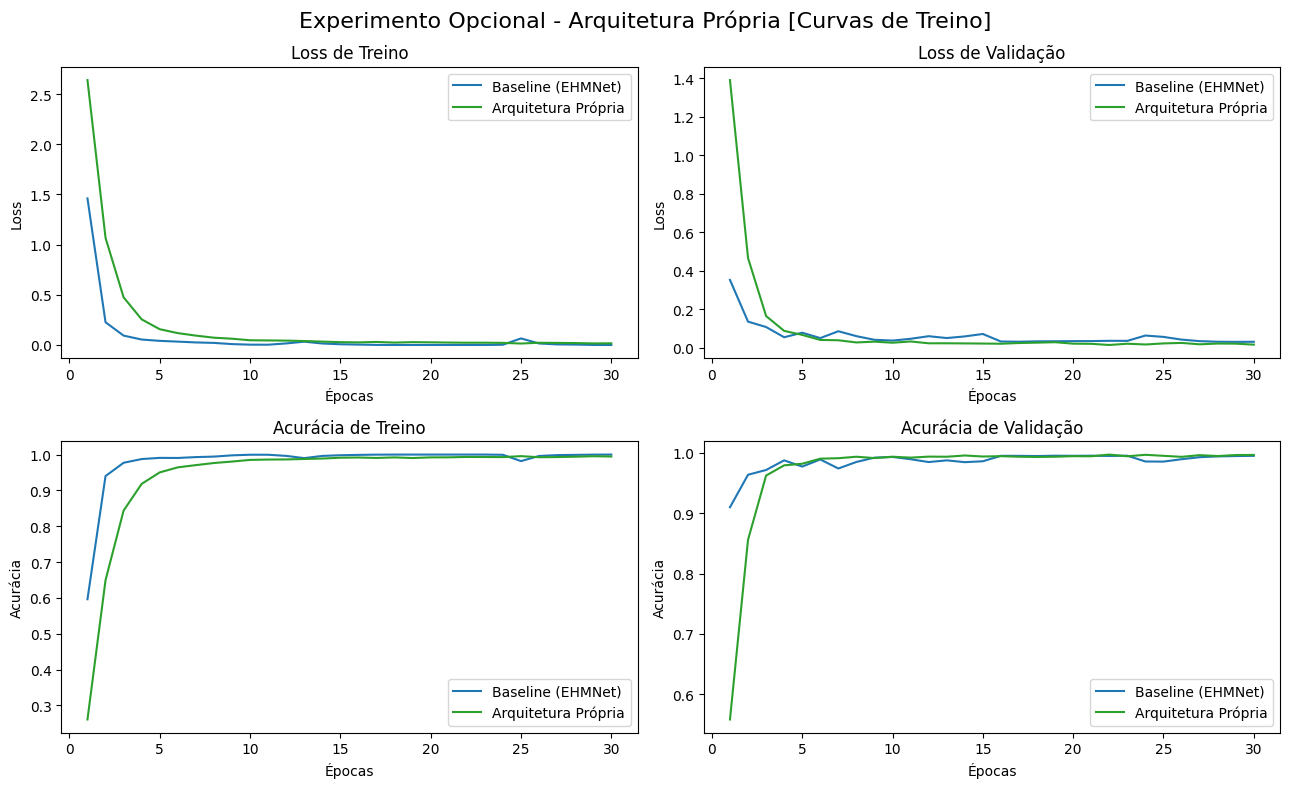

In [14]:
labels = {"baseline": "Baseline (EHMNet)", "custom": "Arquitetura Própria"}
colors = {"baseline": "tab:blue", "custom": "tab:green"}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
epochs = range(1, NUM_EPOCHS + 1)

for name, r in all_results.items():
    axes[0, 0].plot(epochs, r["history"]["train_loss"], label=labels[name], color=colors[name])
axes[0, 0].set_title("Loss de Treino"); axes[0, 0].set_xlabel("Épocas"); axes[0, 0].set_ylabel("Loss"); axes[0, 0].legend()

for name, r in all_results.items():
    axes[0, 1].plot(epochs, r["history"]["val_loss"], label=labels[name], color=colors[name])
axes[0, 1].set_title("Loss de Validação"); axes[0, 1].set_xlabel("Épocas"); axes[0, 1].set_ylabel("Loss"); axes[0, 1].legend()

for name, r in all_results.items():
    axes[1, 0].plot(epochs, r["history"]["train_acc"], label=labels[name], color=colors[name])
axes[1, 0].set_title("Acurácia de Treino"); axes[1, 0].set_xlabel("Épocas"); axes[1, 0].set_ylabel("Acurácia"); axes[1, 0].legend()

for name, r in all_results.items():
    axes[1, 1].plot(epochs, r["history"]["val_acc"], label=labels[name], color=colors[name])
axes[1, 1].set_title("Acurácia de Validação"); axes[1, 1].set_xlabel("Épocas"); axes[1, 1].set_ylabel("Acurácia"); axes[1, 1].legend()

plt.suptitle("Experimento Opcional - Arquitetura Própria [Curvas de Treino]", fontsize=16)
plt.tight_layout()
plt.savefig("figuras/curvas_treino_arquitetura_propria.png", dpi=150, bbox_inches="tight")
plt.show()


### 2. Matrizes de confusão dos dois modelos

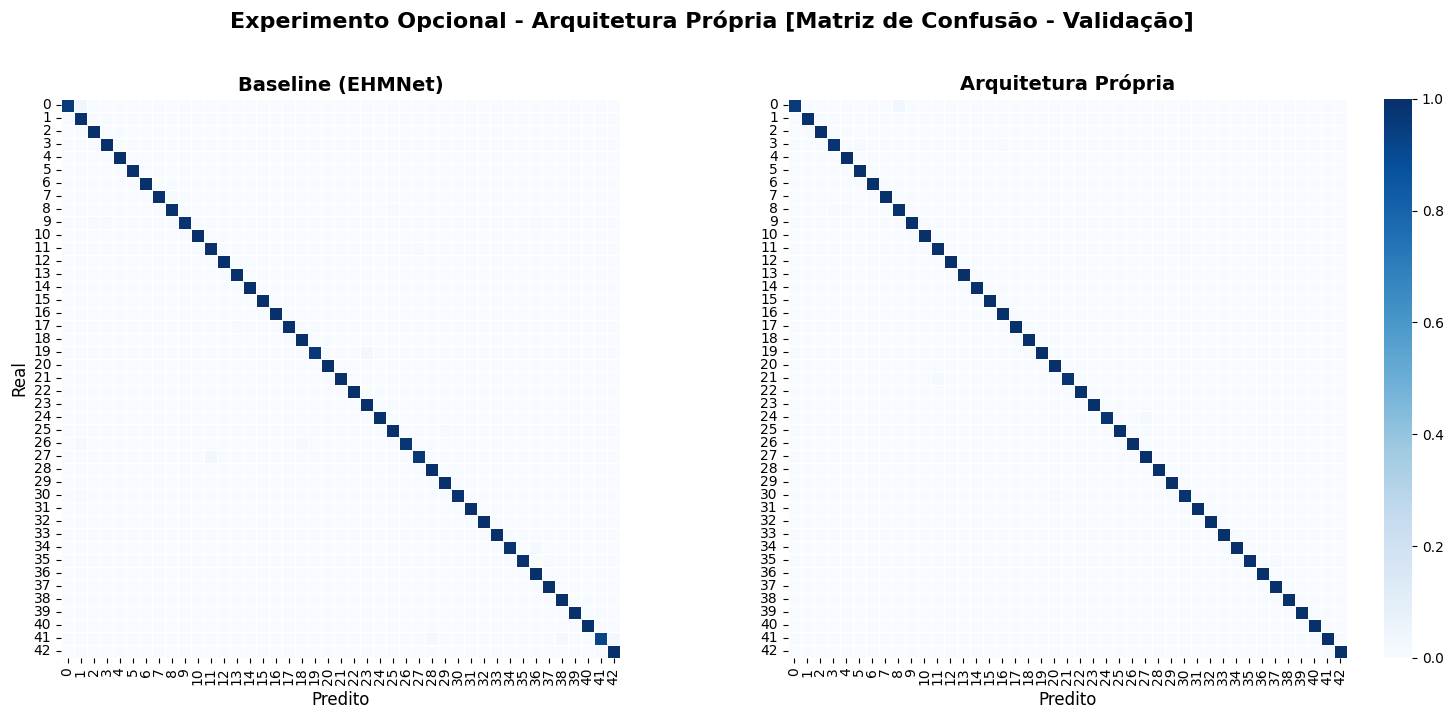

In [15]:
cm = {name: get_confusion_matrix(val_loader, r["model"], device, NUM_CLASSES).cpu().numpy()
      for name, r in all_results.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for i, name in enumerate(["baseline", "custom"]):
    cm_norm = cm[name].astype(float) / cm[name].sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=False,
        xticklabels=np.arange(NUM_CLASSES), yticklabels=np.arange(NUM_CLASSES),
        ax=axes[i], cmap="Blues", cbar=(i == 1), vmin=0, vmax=1,
        linewidths=0.5, linecolor="white", square=True,
    )
    axes[i].set_title(labels[name], fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Predito", fontsize=12)
    axes[i].set_ylabel("Real" if i == 0 else "", fontsize=12)
    axes[i].tick_params(labelsize=10)

plt.suptitle("Experimento Opcional - Arquitetura Própria [Matriz de Confusão - Validação]", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figuras/matrizes_confusao_comparacao_arquitetura.png", dpi=150, bbox_inches="tight")
plt.show()


### 3. Acurácia por classe e macro accuracy

In [16]:
relatorios = {}
for name in ["baseline", "custom"]:
    relatorios[name] = relatorio_por_classe(cm[name], nome_modelo=labels[name])


=== Baseline (EHMNet) ===
Acurácia global (overall): 0.9953
Macro accuracy (média por classe): 0.9930

5 piores classes:
              classe  suporte  acertos  acuracia
   End of no passing       40       37    0.9250
Speed limit (20km/h)       26       25    0.9615
Dangerous curve left       31       30    0.9677
         Pedestrians       34       33    0.9706
     Traffic signals       83       81    0.9759

5 melhores classes:
                     classe  suporte  acertos  acuracia
       Speed limit (50km/h)      296      296       1.0
       Speed limit (70km/h)      269      269       1.0
       Speed limit (60km/h)      182      182       1.0
End of speed limit (80km/h)       63       63       1.0
      No passing veh > 3.5t      281      281       1.0

=== Arquitetura Própria ===
Acurácia global (overall): 0.9972
Macro accuracy (média por classe): 0.9967

5 piores classes:
              classe  suporte  acertos  acuracia
Speed limit (20km/h)       26       25    0.9615
      

In [17]:
metrics_results = {}

for name, r in all_results.items():
    ytrue, ypred = predict(val_loader, r["model"], device)

    per_class_acc = per_class_accuracy(ytrue, ypred)
    global_acc = float((ypred == ytrue).mean())
    macro_acc = float(per_class_acc.mean())

    metrics_results[name] = {
        "ytrue": ytrue,
        "ypred": ypred,
        "per_class_acc": per_class_acc,
        "global_acc": global_acc,
        "macro_acc": macro_acc,
    }

    print(f"{labels[name]}:")
    print(f"  Acurácia Global: {global_acc:.4f}")
    print(f"  Acurácia Macro:  {macro_acc:.4f}\n")


Baseline (EHMNet):
  Acurácia Global: 0.9953
  Acurácia Macro:  0.9930

Arquitetura Própria:
  Acurácia Global: 0.9972
  Acurácia Macro:  0.9967



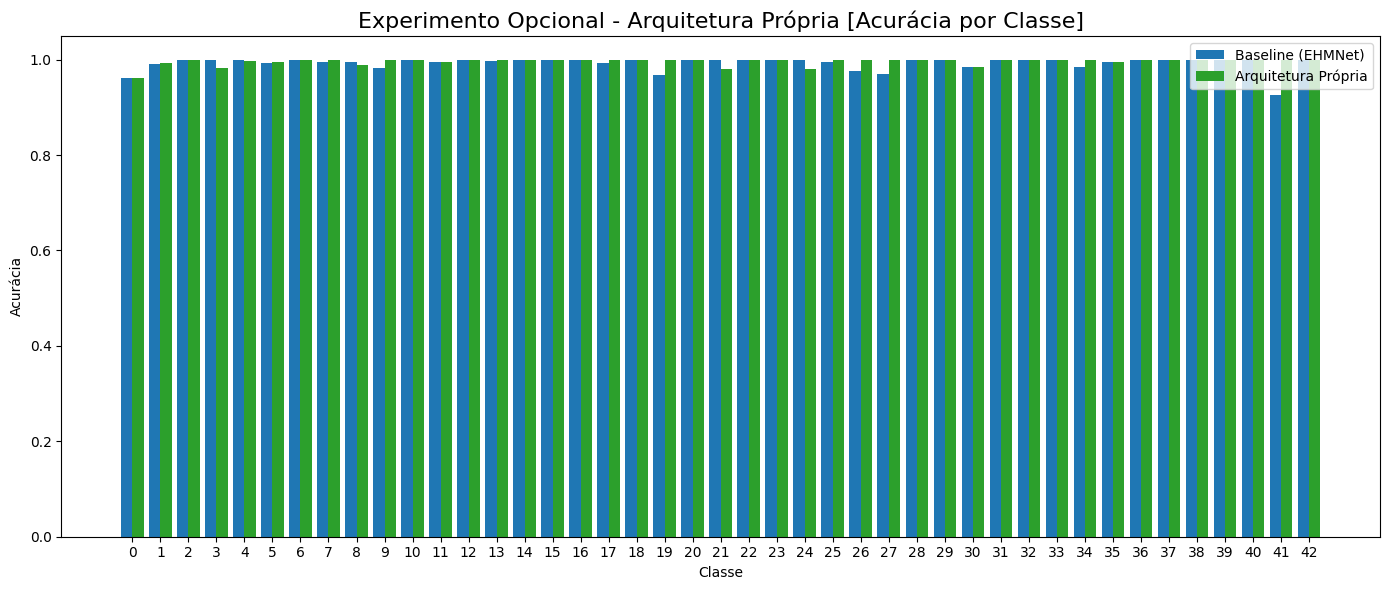

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))
n_series = len(metrics_results)
width = 0.8 / n_series
x = np.arange(NUM_CLASSES)

for i, (name, r) in enumerate(metrics_results.items()):
    offset = (i - (n_series - 1) / 2) * width
    ax.bar(x + offset, r["per_class_acc"], width=width, label=labels[name], color=colors[name])

ax.set_xlabel("Classe")
ax.set_ylabel("Acurácia")
ax.set_title("Experimento Opcional - Arquitetura Própria [Acurácia por Classe]", fontsize=16)
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.savefig("figuras/acuracia_por_classe_arquitetura.png", dpi=150, bbox_inches="tight")
plt.show()


### 4. Predições no conjunto de teste

In [19]:
def predict_test_set(test_loader, model, device):
    model.eval()
    predictions = []
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            predictions.extend(preds)
    return predictions

y_pred_baseline = predict_test_set(test_loader, all_results["baseline"]["model"], device)
save_predictions(y_pred_baseline, "predicoes_baseline_opcional.csv", experiment_name="EHMNet baseline (experimento opcional)")

y_pred_custom = predict_test_set(test_loader, all_results["custom"]["model"], device)
save_predictions(y_pred_custom, "predicoes_arquitetura_propria.csv", experiment_name="EHMNet_Custom (arquitetura propria)")


# Métricas oficiais no conjunto de TESTE (avaliação final)

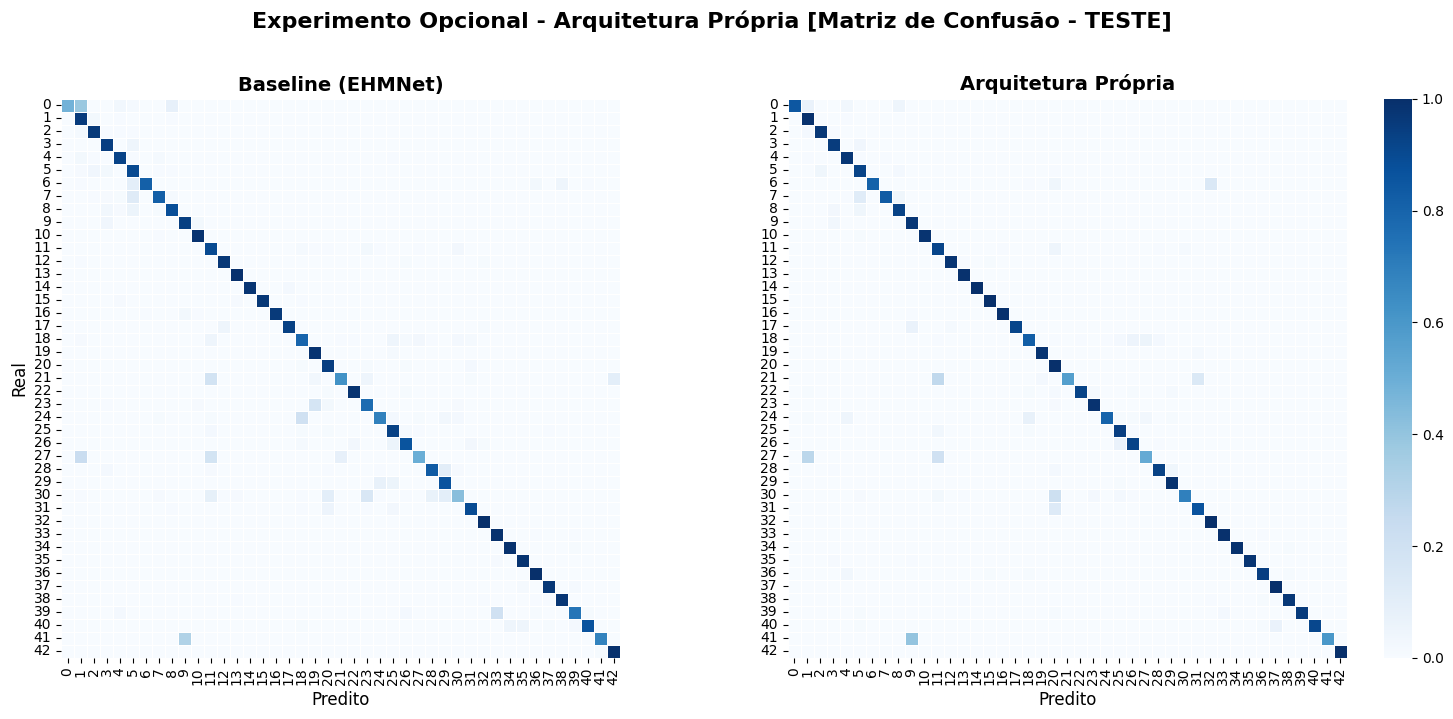

In [20]:
cm_test = {name: get_confusion_matrix(test_loader, r["model"], device, NUM_CLASSES).cpu().numpy()
           for name, r in all_results.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for i, name in enumerate(["baseline", "custom"]):
    cm_norm = cm_test[name].astype(float) / cm_test[name].sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=False,
        xticklabels=np.arange(NUM_CLASSES), yticklabels=np.arange(NUM_CLASSES),
        ax=axes[i], cmap="Blues", cbar=(i == 1), vmin=0, vmax=1,
        linewidths=0.5, linecolor="white", square=True,
    )
    axes[i].set_title(labels[name], fontsize=14, fontweight="bold")
    axes[i].set_xlabel("Predito", fontsize=12)
    axes[i].set_ylabel("Real" if i == 0 else "", fontsize=12)
    axes[i].tick_params(labelsize=10)

plt.suptitle("Experimento Opcional - Arquitetura Própria [Matriz de Confusão - TESTE]", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figuras/matrizes_confusao_teste_arquitetura.png", dpi=150, bbox_inches="tight")
plt.show()


In [21]:
relatorios_teste = {}
for name in ["baseline", "custom"]:
    relatorios_teste[name] = relatorio_por_classe(cm_test[name], nome_modelo=f"{labels[name]} (TESTE)")

metrics_results_teste = {}
for name, r in all_results.items():
    ytrue, ypred = predict(test_loader, r["model"], device)
    per_class_acc = per_class_accuracy(ytrue, ypred)
    global_acc = float((ypred == ytrue).mean())
    macro_acc = float(per_class_acc.mean())
    metrics_results_teste[name] = {
        "ytrue": ytrue,
        "ypred": ypred,
        "per_class_acc": per_class_acc,
        "global_acc": global_acc,
        "macro_acc": macro_acc,
    }
    print(f"{labels[name]} (TESTE):")
    print(f"  Acurácia Global: {global_acc:.4f}")
    print(f"  Acurácia Macro:  {macro_acc:.4f}\n")

resumo_final = pd.DataFrame({
    "modelo": [labels["baseline"], labels["custom"]],
    "acuracia_global_val":   [round(metrics_results["baseline"]["global_acc"], 4), round(metrics_results["custom"]["global_acc"], 4)],
    "acuracia_global_teste": [round(metrics_results_teste["baseline"]["global_acc"], 4), round(metrics_results_teste["custom"]["global_acc"], 4)],
    "macro_accuracy_val":    [round(metrics_results["baseline"]["macro_acc"], 4), round(metrics_results["custom"]["macro_acc"], 4)],
    "macro_accuracy_teste":  [round(metrics_results_teste["baseline"]["macro_acc"], 4), round(metrics_results_teste["custom"]["macro_acc"], 4)],
})
print(resumo_final.to_string(index=False))


=== Baseline (EHMNet) (TESTE) ===
Acurácia global (overall): 0.9169
Macro accuracy (média por classe): 0.8742

5 piores classes:
              classe  suporte  acertos  acuracia
  Beware of ice/snow      150       64    0.4267
Speed limit (20km/h)       60       29    0.4833
         Pedestrians       60       30    0.5000
        Double curve       90       56    0.6222
   End of no passing       60       41    0.6833

5 melhores classes:
                    classe  suporte  acertos  acuracia
      Go straight or right      120      120    1.0000
End speed + passing limits       60       60    1.0000
                     Yield      720      715    0.9931
           Turn left ahead      120      119    0.9917
          Turn right ahead      210      208    0.9905

=== Arquitetura Própria (TESTE) ===
Acurácia global (overall): 0.9401
Macro accuracy (média por classe): 0.9132

5 piores classes:
            classe  suporte  acertos  acuracia
       Pedestrians       60       31    0.5167


### Overfitting --> comparação entre treino e validação

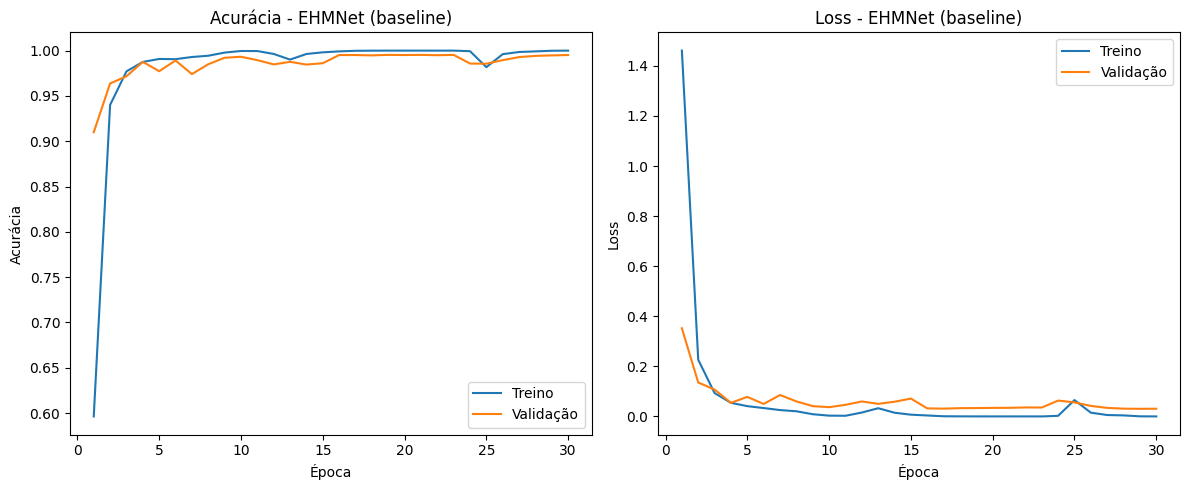

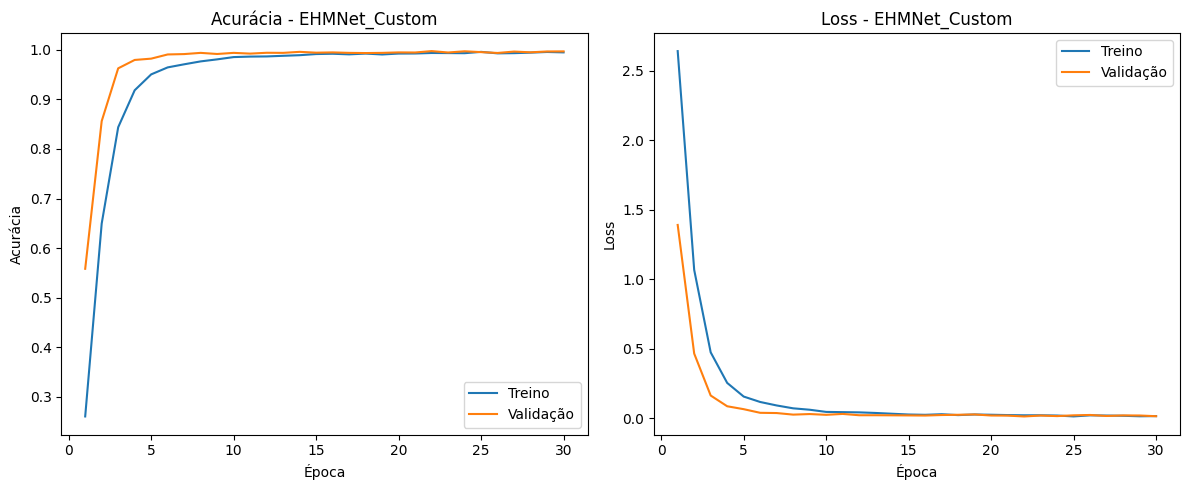

In [22]:
def plot_overfitting_check(history, model_name):
    epochs = range(1, len(history['train_acc']) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_acc'], label='Treino')
    plt.plot(epochs, history['val_acc'], label='Validação')
    plt.xlabel('Época')
    plt.ylabel('Acurácia')
    plt.title(f'Acurácia - {model_name}')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_loss'], label='Treino')
    plt.plot(epochs, history['val_loss'], label='Validação')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.title(f'Loss - {model_name}')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"figuras/overfitting_{model_name}.png", dpi=150, bbox_inches='tight')
    plt.show()

plot_overfitting_check(res_baseline["history"], "EHMNet (baseline)")
plot_overfitting_check(res_custom["history"], "EHMNet_Custom")
